# Interactive Plotting (Full Hierarchy)
Trực quan hóa tương tác theo Mã cổ phiếu (Ticker) với 3 cấp độ: Market, Sector, Ticker.

In [16]:
import pandas as pd
import numpy as np
import ipywidgets as widgets
from ipywidgets import interactive_output
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

print('Đang tải dữ liệu...')
df_market = pd.read_parquet(r'c:\Users\ADMIN\Desktop\Kaggle\output\hmm_v3_op1_extended\market_regimes.parquet')
# df_daily_market = pd.read_parquet(r'c:\Users\ADMIN\Desktop\Kaggle\output\hmm_v3_op1_extended\daily_market_regimes.parquet')
df_sector = pd.read_parquet(r'c:\Users\ADMIN\Desktop\Kaggle\output\hmm_v3_op1_extended\sector_regimes.parquet')
df_master = pd.read_parquet(r'c:\Users\ADMIN\Desktop\Kaggle\output\hmm_v3_op1_extended\master_drl_ready_full.parquet')

# df_daily_market['time'] = pd.to_datetime(df_daily_market['time'])
df_master['time'] = pd.to_datetime(df_master['time'])
df_sector['time'] = pd.to_datetime(df_sector['time'])
df_sector['sector_close'] = df_sector.groupby('industry')['sector_log_ret'].transform(lambda x: np.exp(x.cumsum()) * 100)
df_master = df_master.merge(df_sector[['time', 'industry', 'sector_close']], on=['time', 'industry'], how='left')
print(df_market['market_regime_label'].unique().tolist())

# Gộp dữ liệu để có true_market_regime
df_plot = df_master.copy()
df_plot['true_market_regime'] = df_plot['market_regime_label']
# df_plot = df_plot.merge(df_market_true, on='time', how='left')

SEMANTIC_COLORS = {
    'Bull': '#2ecc71',
    'CalmBull': '#2ecc71',
    'Bear': '#e74c3c',
    'Crisis': '#e74c3c',
    'Euphoria': '#f39c12',
    'Sideways': '#95a5a6',
    'Tranquil': '#95a5a6',
}

def get_color(label):
    return SEMANTIC_COLORS.get(str(label).strip(), '#e0e0e0')

def plot_ticker_regimes(ticker, date_range):
    sub_df = df_plot[
        (df_plot['ticker'] == ticker) &
        (df_plot['time'] >= date_range[0]) &
        (df_plot['time'] <= date_range[1])
    ].copy().sort_values('time').reset_index(drop=True)
    
    if len(sub_df) == 0:
        print('Không có dữ liệu cho khoảng thời gian này.')
        return
        
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(16, 18), sharex=True, gridspec_kw={'height_ratios': [3, 3, 3, 1.5, 1.5]})
    times = sub_df['time']
    
    # 1. Market Regime vs VN-Index Close
    ax1.set_title(f"Mã: {ticker} | Ngành: {sub_df['industry'].iloc[0]}", fontsize=16, fontweight='bold')
    ax1.set_ylabel('VN-Index (Market)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    m_regimes = sub_df['true_market_regime']
    for i in range(1, len(sub_df)):
        if pd.notna(m_regimes.iloc[i]):
            c = get_color(m_regimes.iloc[i])
            ax1.plot([times.iloc[i-1], times.iloc[i]], [sub_df['vnindex_close'].iloc[i-1], sub_df['vnindex_close'].iloc[i]], color=c, linewidth=1.5)
        
    present_market = sorted(m_regimes.dropna().unique())
    legend_elements_1 = [Patch(facecolor=get_color(reg), edgecolor='none', label=f'Market: {reg}') for reg in present_market]
    ax1.legend(handles=legend_elements_1, loc='upper left', bbox_to_anchor=(1.01, 1))
    
    # 2. Sector Regime vs Ticker Close
    ax2.set_ylabel('Chỉ số Ngành (Sector)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    s_regimes = sub_df['sector_regime_label']
    for i in range(1, len(sub_df)):
        if pd.notna(s_regimes.iloc[i]):
            c = get_color(s_regimes.iloc[i])
            ax2.plot([times.iloc[i-1], times.iloc[i]], [sub_df['sector_close'].iloc[i-1], sub_df['sector_close'].iloc[i]], color=c, linewidth=1.5)
        
    present_sector = sorted(s_regimes.dropna().unique())
    legend_elements_2 = [Patch(facecolor=get_color(reg), edgecolor='none', label=f'Sector: {reg}') for reg in present_sector]
    ax2.legend(handles=legend_elements_2, loc='upper left', bbox_to_anchor=(1.01, 1))

    # 3. Ticker Regime vs Ticker Close
    ax3.set_ylabel('Giá Mã (Ticker)', fontsize=12)
    ax3.grid(True, alpha=0.3)
    
    t_regimes = sub_df['ticker_regime_label']
    for i in range(1, len(sub_df)):
        if pd.notna(t_regimes.iloc[i]):
            c = get_color(t_regimes.iloc[i])
            ax3.plot([times.iloc[i-1], times.iloc[i]], [sub_df['close'].iloc[i-1], sub_df['close'].iloc[i]], color=c, linewidth=1.5)
        
    present_ticker = sorted(t_regimes.dropna().unique())
    legend_elements_3 = [Patch(facecolor=get_color(reg), edgecolor='none', label=f'Ticker: {reg}') for reg in present_ticker]
    ax3.legend(handles=legend_elements_3, loc='upper left', bbox_to_anchor=(1.01, 1))
    
    # 4. Volume
    ax4.bar(times, sub_df['volume'], color='grey', alpha=0.6, label='Volume')
    ax4.set_ylabel('Khối Lượng', fontsize=12)
    ax4.grid(True, alpha=0.3)
    
    # 5. Meta-Classifier Prob
    if 'final_meta_pred_prob' in sub_df.columns:
        ax5.plot(times, sub_df['final_meta_pred_prob'], color='blue', linewidth=1.5, label='Xác suất tăng T+1 (Meta)')
        ax5.axhline(0.5, color='red', linestyle='--', alpha=0.5)
        ax5.fill_between(times, sub_df['final_meta_pred_prob'], 0.5, where=(sub_df['final_meta_pred_prob'] > 0.5), color='#2ecc71', alpha=0.3)
        ax5.fill_between(times, sub_df['final_meta_pred_prob'], 0.5, where=(sub_df['final_meta_pred_prob'] <= 0.5), color='#e74c3c', alpha=0.3)
        ax5.set_ylabel('Xác suất Tăng', fontsize=12)
        ax5.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
        ax5.set_ylim(0, 1)
    
    ax5.set_xlabel('Thời Gian', fontsize=12)
    ax5.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

tickers = sorted(df_plot['ticker'].dropna().unique())
dates = sorted(df_plot['time'].unique())

ticker_dropdown = widgets.Dropdown(options=tickers, value=tickers[0], description='Mã Ticker:')
date_slider = widgets.SelectionRangeSlider(options=dates, index=(0, len(dates)-1), description='Khoảng Đo:', orientation='horizontal', layout={'width': '80%'})

ui = widgets.VBox([ticker_dropdown, date_slider])
out = interactive_output(plot_ticker_regimes, {'ticker': ticker_dropdown, 'date_range': date_slider})

display(ui, out)


Đang tải dữ liệu...
['Bear', 'Bull']


Output()

Đang vẽ biểu đồ tĩnh cho BID...


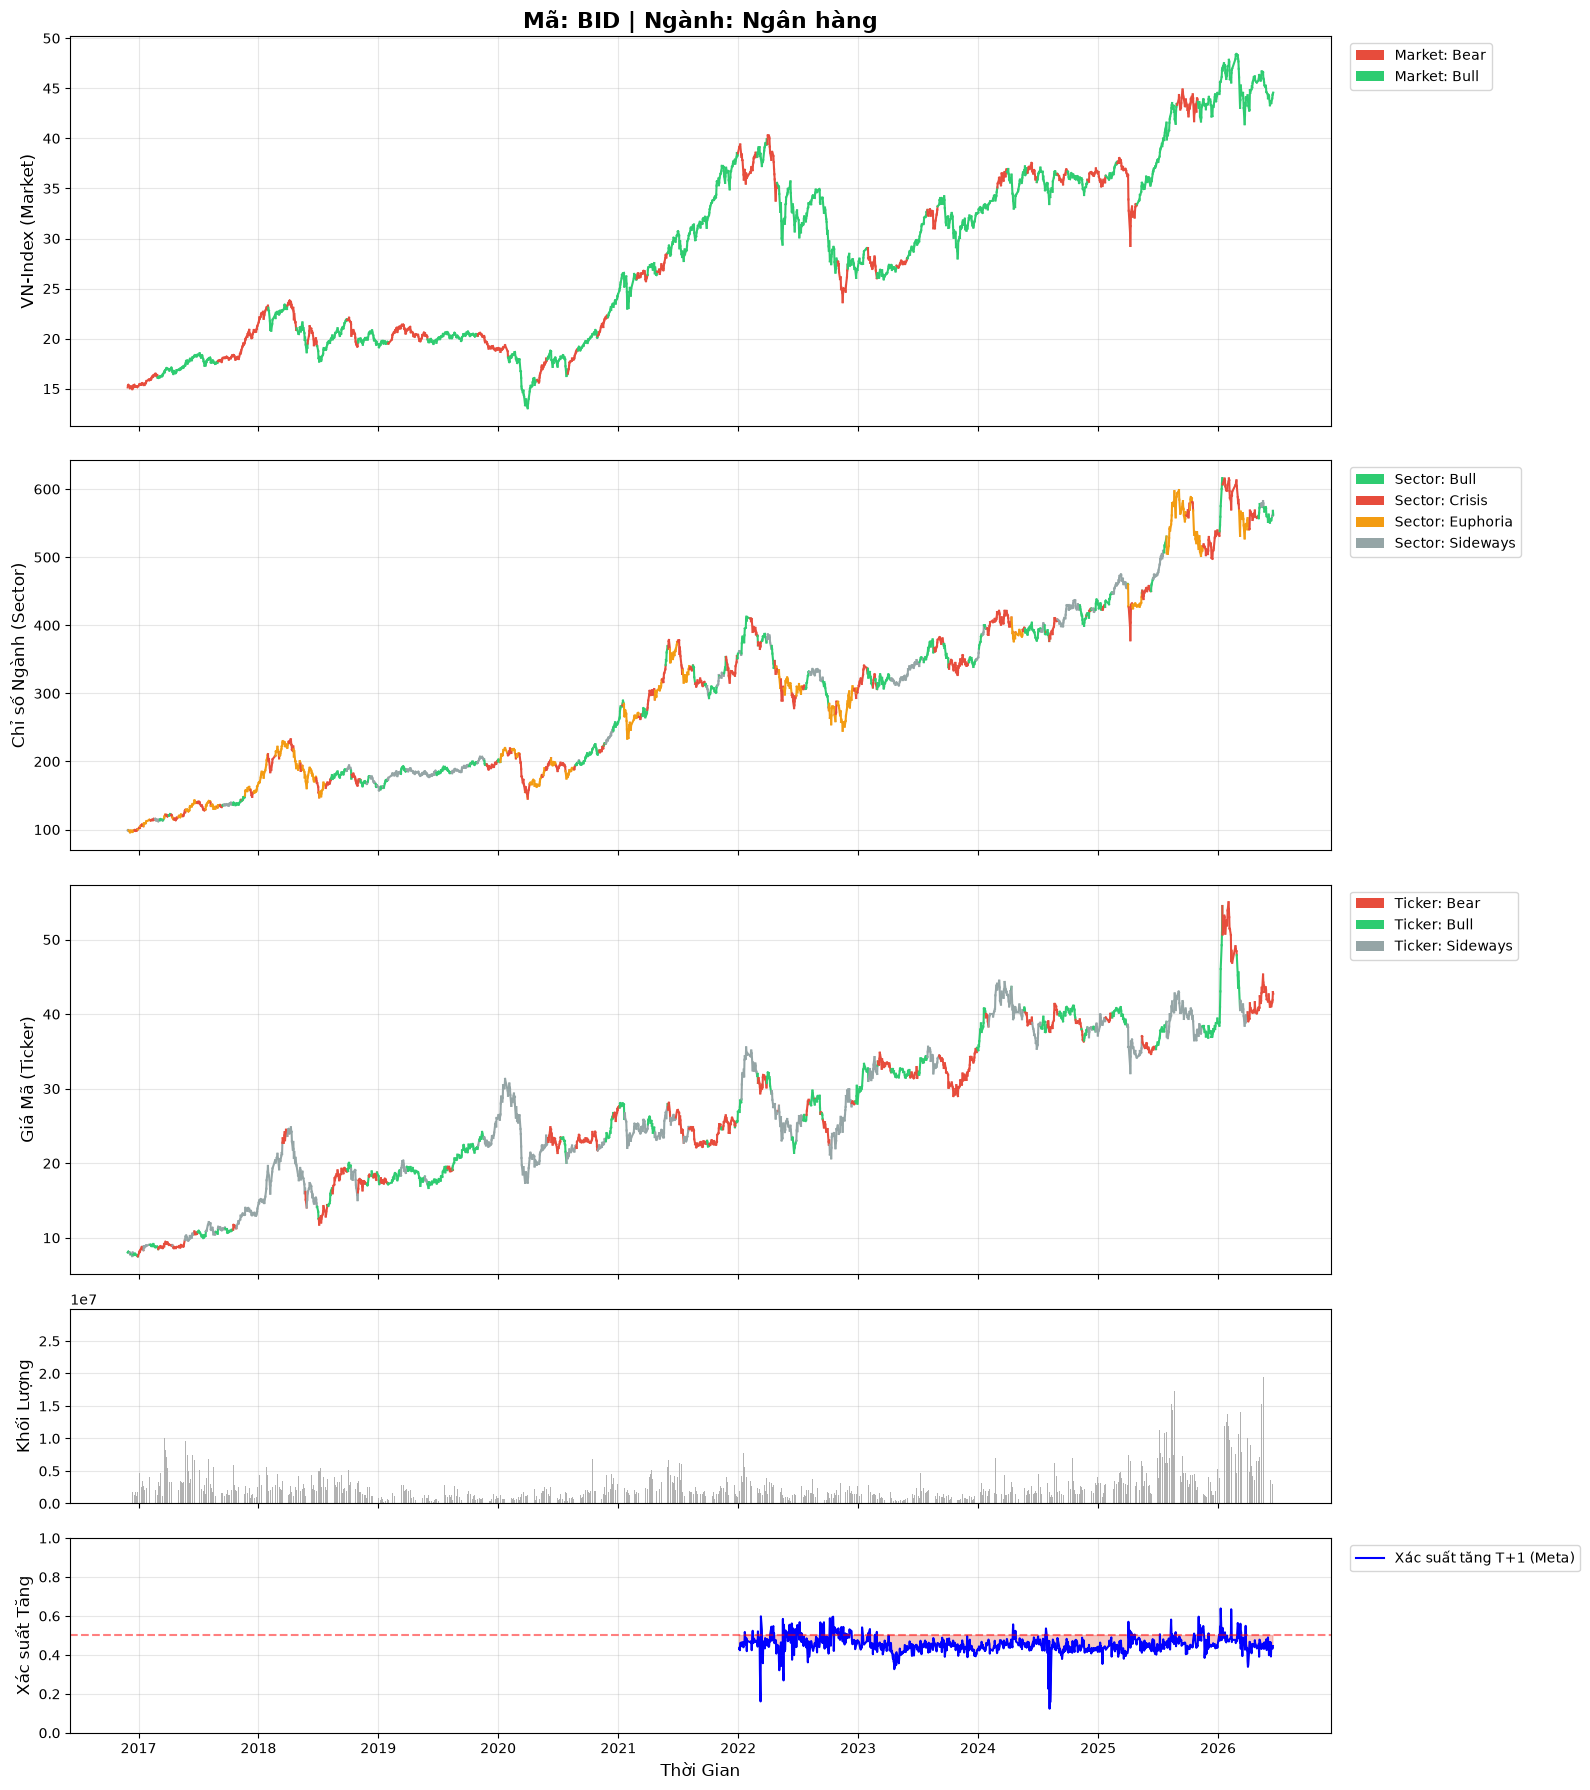

In [17]:
ticker_to_plot = 'BID'
date_range = (df_plot['time'].min(), df_plot['time'].max())

print(f"Đang vẽ biểu đồ tĩnh cho {ticker_to_plot}...")
plot_ticker_regimes(ticker_to_plot, date_range)